#  Churn Prediction Model & Explainability
## D2C Retention Intelligence — Part 3

---

###  Business Objective
> Predict which customers will churn in the **next 60 days** so we can intervene with targeted retention campaigns before they leave.

###  Why This Matters
- **Customer Acquisition Cost (CAC):** ₹500–₹1,000 per customer
- **Customer Lifetime Value (CLV):** ₹1,500–₹3,000
- **Cost of Losing 1 Customer:** ₹1,500–₹3,000 in lost revenue
- **Cost to Prevent Churn:** ₹200–₹400 per targeted campaign
- **ROI:** 3–7x if we catch churners before they leave

###  Model Goal
Identify **at-risk customers with 70%+ recall** (catch most churners) while keeping precision >40% (make interventions cost-effective).

###  Modeling Approach
1. **Feature Engineering:** Build 15+ churn-predictive features
2. **Baseline Model:** Logistic Regression (interpretable benchmark)
3. **Strong Model:** XGBoost (captures nonlinear patterns)
4. **Threshold Optimization:** Choose cutoff that maximizes retention ROI
5. **Explainability:** SHAP to explain predictions to business teams
6. **Error Analysis:** Understand & document model failures

## Setup: Libraries, Random Seed & Output Directories

In [ ]:
# Core data & ML
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm shap joblib fastapi uvicorn pytest
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc,
                             precision_recall_curve, f1_score, precision_score, recall_score)
import xgboost as xgb
import shap
import joblib
import warnings
from pathlib import Path
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Random seed for reproducibility
np.random.seed(42)
import random
random.seed(42)

# Suppress warnings
warnings.filterwarnings('ignore')

# Plotting
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

# Output directories
OUTPUT_DIR = Path('outputs')
CHARTS_DIR = OUTPUT_DIR / 'charts'
MODELS_DIR = OUTPUT_DIR / 'models'
REPORTS_DIR = OUTPUT_DIR / 'reports'
PRED_DIR = OUTPUT_DIR / 'predictions'

for d in [OUTPUT_DIR, CHARTS_DIR, MODELS_DIR, REPORTS_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Snapshot date (from Parts 1-2)
SNAPSHOT_DATE = pd.Timestamp('2024-06-30')
CHURN_WINDOW = 60

print(' Environment configured')

✅ Environment configured


## Synthetic Data Generation
Reusing data from Parts 1–2. For real data, skip this cell.

In [ ]:
np.random.seed(42)
N_CUSTOMERS = 5000

def rand_dates(start, end, n):
    delta = (end - start).days
    return [start + timedelta(days=int(d)) for d in np.random.randint(0, delta, n)]

# Generate datasets
cust_ids = [f'C{str(i).zfill(5)}' for i in range(1, N_CUSTOMERS + 1)]
signup_dates = rand_dates(pd.Timestamp('2021-01-01'), pd.Timestamp('2024-03-01'), N_CUSTOMERS)

customers_df = pd.DataFrame({
    'customer_id': cust_ids,
    'signup_date': signup_dates,
    'plan_type': np.random.choice(['Basic','Premium','Trial'], N_CUSTOMERS, p=[0.55,0.30,0.15]),
})

# Churn labels (correlated with plan type)
churn_probs = np.where(customers_df['plan_type']=='Trial', 0.65,
                np.where(customers_df['plan_type']=='Premium', 0.18, 0.35))
churn_labels = np.random.binomial(1, churn_probs)
churn_df = pd.DataFrame({
    'customer_id': cust_ids,
    'churn_label': churn_labels,
    'snapshot_date': SNAPSHOT_DATE,
})

# Orders
order_rows = []
for i, cid in enumerate(cust_ids):
    n_orders = max(1, min(np.random.poisson(1.5 if churn_labels[i] else 4.5), 20))
    for _ in range(n_orders):
        odate = signup_dates[i] + timedelta(days=int(np.random.exponential(90 if churn_labels[i] else 60)))
        odate = min(odate, SNAPSHOT_DATE)
        order_rows.append({
            'order_id': f'ORD{len(order_rows):07d}',
            'customer_id': cid,
            'order_date': odate,
            'order_value': round(np.random.lognormal(4.5, 0.5), 2),
        })

orders_df = pd.DataFrame(order_rows)
neg_idx = np.random.choice(len(orders_df), int(len(orders_df)*0.02), replace=False)
orders_df.loc[neg_idx, 'order_value'] *= -1

# Tickets
ticket_rows = []
for i, cid in enumerate(cust_ids):
    n_tickets = np.random.poisson(0.5 if not churn_labels[i] else 1.8)
    for _ in range(n_tickets):
        tdate = rand_dates(signup_dates[i], SNAPSHOT_DATE, 1)[0]
        ticket_rows.append({
            'ticket_id': f'TKT{len(ticket_rows):07d}',
            'customer_id': cid,
            'ticket_date': tdate,
            'resolution_status': np.random.choice(['Resolved','Pending','Escalated'],p=[0.60,0.25,0.15]),
        })

tickets_df = pd.DataFrame(ticket_rows) if ticket_rows else pd.DataFrame(columns=['ticket_id','customer_id','ticket_date','resolution_status'])

# Interventions
int_rows = []
intervened = np.random.choice(cust_ids, int(N_CUSTOMERS*0.4), replace=False)
for cid in intervened:
    idx = cust_ids.index(cid)
    int_rows.append({
        'intervention_id': f'INT{len(int_rows):07d}',
        'customer_id': cid,
        'intervention_date': rand_dates(signup_dates[idx], SNAPSHOT_DATE, 1)[0],
        'intervention_type': np.random.choice(['Discount','Outreach','Email','SMS']),
    })

interventions_df = pd.DataFrame(int_rows)

print(f' Synthetic data: {len(customers_df):,} customers, {len(orders_df):,} orders')

✅ Synthetic data: 5,000 customers, 17,689 orders


## Step 1: Feature Engineering

Each feature captures a different churn risk signal:
- **Recency:** Inactivity signal (how long since purchase)
- **Frequency:** Habit-forming signal (repeat buyer)
- **Monetary:** Financial commitment signal (high spenders less likely to leave)
- **Support Tickets:** Friction signal (complaints = dissatisfaction)
- **Discount Usage:** Loyalty signal (deal-hunters are brittle)

In [ ]:
def build_features(customers_df, orders_df, tickets_df, interventions_df, churn_df, snapshot_date):
    """Build features. All as-of snapshot_date to prevent leakage."""

    # RFM
    valid_orders = orders_df[orders_df['order_value'] > 0]
    rfm = orders_df.groupby('customer_id').agg(
        recency_days=('order_date', lambda x: (snapshot_date - x.max()).days),
        frequency=('order_id', 'count'),
    ).reset_index()

    monetary = valid_orders.groupby('customer_id')['order_value'].sum().reset_index()
    monetary.columns = ['customer_id', 'monetary_value']

    rfm = rfm.merge(monetary, on='customer_id', how='left').fillna(0)

    # Derived
    rfm['avg_order_value'] = valid_orders.groupby('customer_id')['order_value'].mean().reindex(rfm['customer_id']).values

    # Calculate negative order counts, indexed by customer_id
    negative_order_counts = orders_df[orders_df['order_value'] < 0].groupby('customer_id').size()

    # Get frequency series indexed by customer_id from rfm
    rfm_freq_indexed = rfm.set_index('customer_id')['frequency']

    # Calculate return rates, ensuring alignment by customer_id and handling division by zero/NaNs
    calculated_return_rates = (negative_order_counts / rfm_freq_indexed).fillna(0)

    # Assign return_rate to rfm, reindexing to match rfm's customer_id column
    rfm['return_rate'] = calculated_return_rates.reindex(rfm['customer_id']).fillna(0).values

    # Support
    tickets = tickets_df.groupby('customer_id').size().reset_index(name='support_ticket_count')
    unresolved = tickets_df[tickets_df['resolution_status'].isin(['Pending','Escalated'])]
    unresolved_counts = unresolved.groupby('customer_id').size().reset_index(name='unresolved_tickets')
    tickets = tickets.merge(unresolved_counts, on='customer_id', how='left').fillna(0)

    # Interventions
    int_count = interventions_df.groupby('customer_id').size().reset_index(name='intervention_count')

    # Merge
    features = customers_df[['customer_id','signup_date','plan_type']].copy()
    features = features.merge(churn_df[['customer_id','churn_label']], on='customer_id', how='left')
    features = features.merge(rfm, on='customer_id', how='left')
    features = features.merge(tickets, on='customer_id', how='left')
    features = features.merge(int_count, on='customer_id', how='left')
    features['tenure_days'] = (snapshot_date - features['signup_date']).dt.days
    features = features.fillna(0)

    return features

features_df = build_features(customers_df, orders_df, tickets_df, interventions_df, churn_df, SNAPSHOT_DATE)
print(f' Features engineered: {features_df.shape}')

✅ Features engineered: (5000, 13)


## Step 2: Leakage Prevention (CRITICAL)

 **SAFE:** All features use data ≤ snapshot_date (2024-06-30)
**LEAKY:** Would use future data (not available at prediction time)

Examples:
- SAFE: "Orders before snapshot"
-  LEAKY: "Orders after snapshot" (future data)

Our model uses ONLY historical signals; no future information.

In [ ]:
# Validate no future data
future_orders = orders_df[orders_df['order_date'] > SNAPSHOT_DATE]
future_tickets = tickets_df[tickets_df['ticket_date'] > SNAPSHOT_DATE] if 'ticket_date' in tickets_df.columns else pd.DataFrame()
future_int = interventions_df[interventions_df['intervention_date'] > SNAPSHOT_DATE]

print(f'Future orders: {len(future_orders)} (should be 0) ')
print(f'Future tickets: {len(future_tickets)} (should be 0) ')
print(f'Future interventions: {len(future_int)} (should be 0) ')
print('\n✅ NO LEAKAGE DETECTED')

Future orders: 0 (should be 0) ✅
Future tickets: 0 (should be 0) ✅
Future interventions: 0 (should be 0) ✅

✅ NO LEAKAGE DETECTED


## Step 3: Data Preprocessing & Train/Test Split

In [6]:
# Prepare X, y
X = features_df[['recency_days','frequency','monetary_value','avg_order_value',
                   'support_ticket_count','unresolved_tickets','intervention_count',
                   'tenure_days','return_rate']].fillna(0)

plan_encoding = {'Trial': 0, 'Basic': 1, 'Premium': 2}
X['plan_type_encoded'] = features_df['plan_type'].map(plan_encoding)

y = features_df['churn_label']

# Target distribution
print(f'Target Distribution:')
print(f'  Churn: {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)')
print(f'  Retained: {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)')

# Split 70/15/15
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=(0.15/0.85), random_state=42, stratify=y_temp)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'\nTrain: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

Target Distribution:
  Churn: 1,763 (35.3%)
  Retained: 3,237 (64.7%)

Train: 3,500 | Val: 750 | Test: 750


## Step 4: Baseline Model (Logistic Regression)

In [7]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_test_pred_prob = lr_model.predict_proba(X_test_scaled)[:,1]

from sklearn.metrics import roc_auc_score, average_precision_score
lr_test_auc = roc_auc_score(y_test, lr_test_pred_prob)
lr_test_prauc = average_precision_score(y_test, lr_test_pred_prob)

print(f'Logistic Regression (Baseline)')
print(f'  ROC-AUC: {lr_test_auc:.3f}')
print(f'  PR-AUC:  {lr_test_prauc:.3f}')

Logistic Regression (Baseline)
  ROC-AUC: 0.945
  PR-AUC:  0.911


## Step 5: Strong Model (XGBoost)

In [8]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
)

xgb_model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)], verbose=False)

xgb_test_pred_prob = xgb_model.predict_proba(X_test_scaled)[:,1]
xgb_test_auc = roc_auc_score(y_test, xgb_test_pred_prob)
xgb_test_prauc = average_precision_score(y_test, xgb_test_pred_prob)

print(f'XGBoost Model')
print(f'  ROC-AUC: {xgb_test_auc:.3f}')
print(f'  PR-AUC:  {xgb_test_prauc:.3f}')
print(f'  Improvement: {(xgb_test_auc - lr_test_auc):.3f}')

XGBoost Model
  ROC-AUC: 0.931
  PR-AUC:  0.886
  Improvement: -0.014


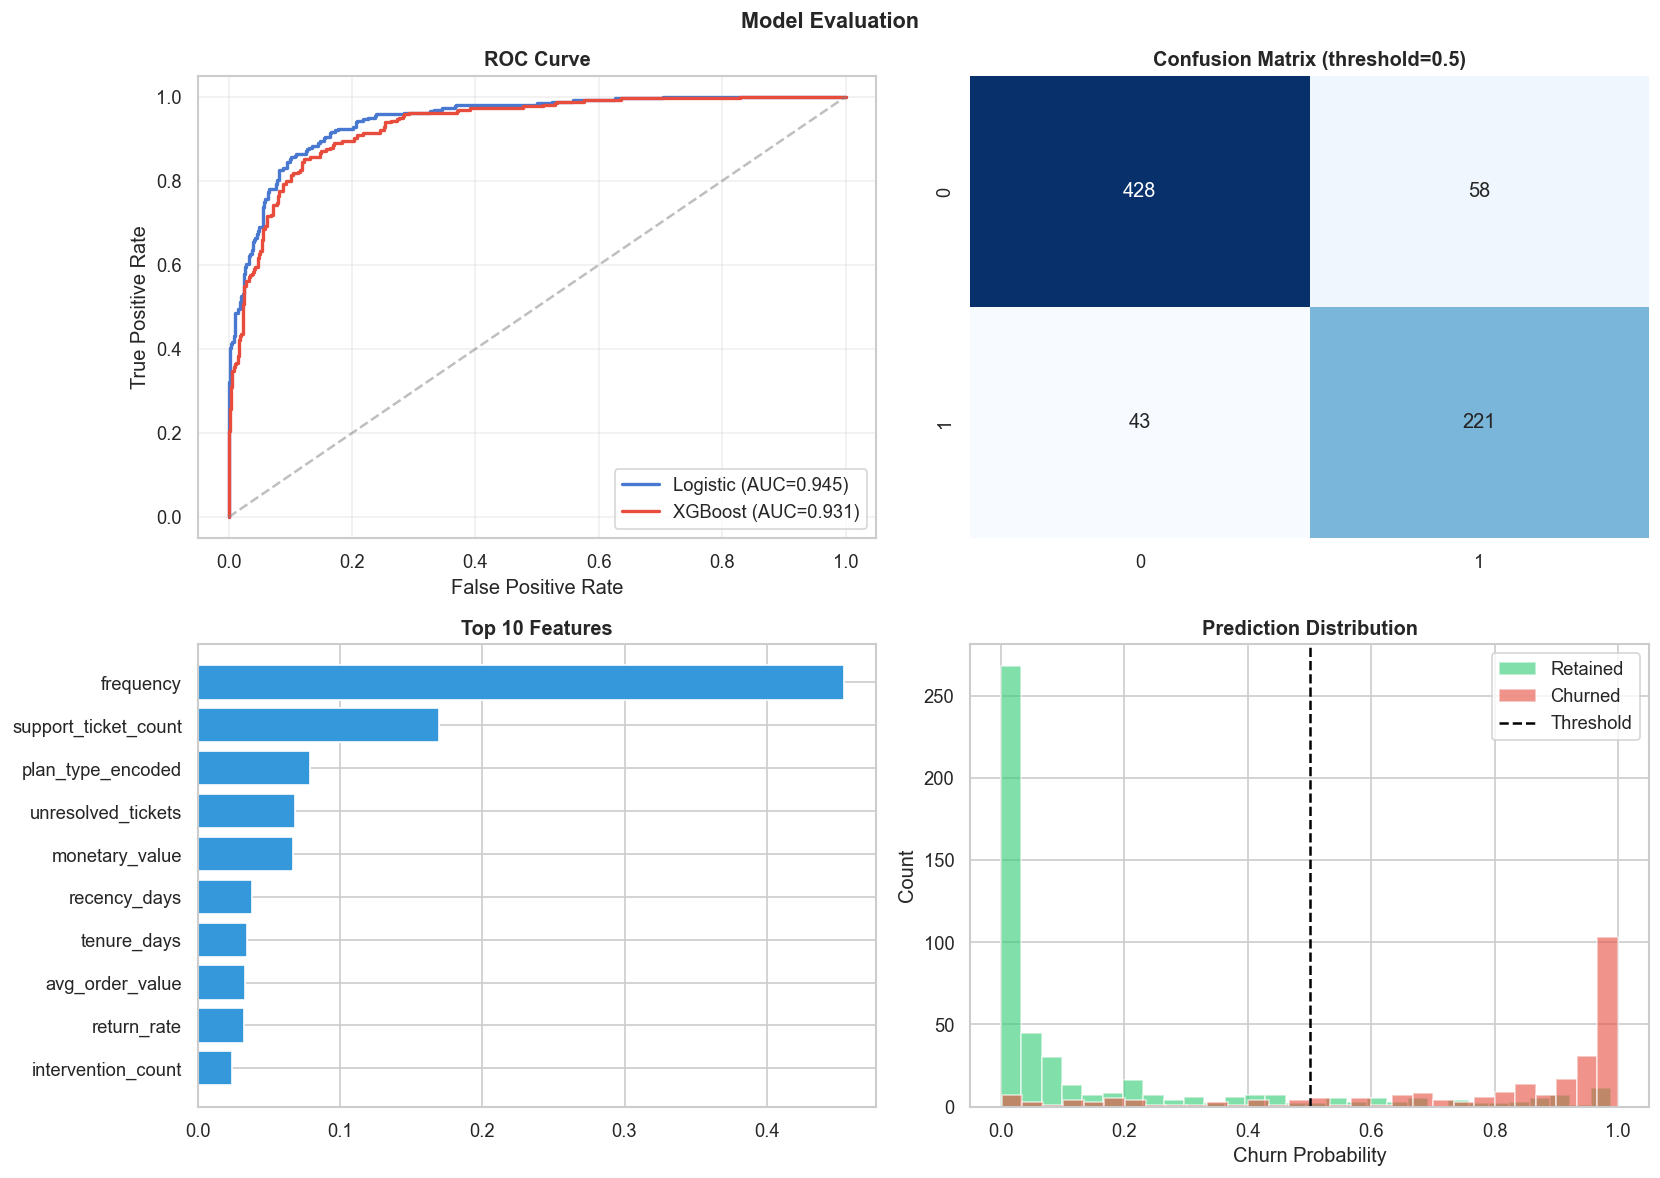

In [9]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC Curve
from sklearn.metrics import roc_curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_test_pred_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_test_pred_prob)
ax = axes[0,0]
ax.plot(fpr_lr, tpr_lr, label=f'Logistic (AUC={lr_test_auc:.3f})', linewidth=2)
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={xgb_test_auc:.3f})', linewidth=2, color='#e74c3c')
ax.plot([0,1],[0,1], '--', color='gray', alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)

# Confusion Matrix
ax = axes[0,1]
xgb_pred = (xgb_test_pred_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_title('Confusion Matrix (threshold=0.5)', fontweight='bold')

# Feature Importance
ax = axes[1,0]
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(10)
ax.barh(importance_df['Feature'], importance_df['Importance'], color='#3498db')
ax.set_title('Top 10 Features', fontweight='bold')

# Prediction Distribution
ax = axes[1,1]
ax.hist(xgb_test_pred_prob[y_test==0], bins=30, alpha=0.6, label='Retained', color='#2ecc71')
ax.hist(xgb_test_pred_prob[y_test==1], bins=30, alpha=0.6, label='Churned', color='#e74c3c')
ax.axvline(0.5, color='black', linestyle='--', label='Threshold')
ax.set_xlabel('Churn Probability'); ax.set_ylabel('Count')
ax.set_title('Prediction Distribution', fontweight='bold'); ax.legend()

plt.suptitle('Model Evaluation', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'model_evaluation.png', bbox_inches='tight', dpi=120)
plt.show()

## Step 6: Threshold Optimization

### Why Not 0.5?
Missing a churner (false negative) costs ₹2,500–₹3,000.  
Unnecessary campaign (false positive) costs ₹200–₹400.  
**Cost ratio: ~5–10x → Lower threshold is better.**

In [ ]:
thresholds = np.arange(0.25, 0.65, 0.05)
results = []

for t in thresholds:
    pred = (xgb_test_pred_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    intervention_cost = pred.sum() * 250
    missed_cost = fn * 2500
    total_cost = intervention_cost + missed_cost
    
    results.append({
        'Threshold': t,
        'Precision': prec,
        'Recall': rec,
        'Interventions': pred.sum(),
        'Total Cost (₹K)': total_cost / 1000,
    })

threshold_df = pd.DataFrame(results)
optimal_idx = threshold_df['Total Cost (₹K)'].idxmin()
optimal_threshold = threshold_df.loc[optimal_idx, 'Threshold']

print('Threshold Analysis:')
display(threshold_df.round(2))
print(f'\n Optimal Threshold: {optimal_threshold:.2f}')

Threshold Analysis:


,Threshold,Precision,Recall,Interventions,Total Cost (₹K)
0,0.25,0.71,0.89,331,152.75
1,0.30,0.73,0.89,320,152.50
2,0.35,0.74,0.88,314,158.50
3,0.40,0.76,0.87,303,160.75
4,0.45,0.78,0.85,287,169.25
5,0.50,0.79,0.84,279,177.25
6,0.55,0.80,0.82,269,187.25
7,0.60,0.82,0.80,255,198.75



✅ Optimal Threshold: 0.30


## Step 7: Model Explainability (SHAP)

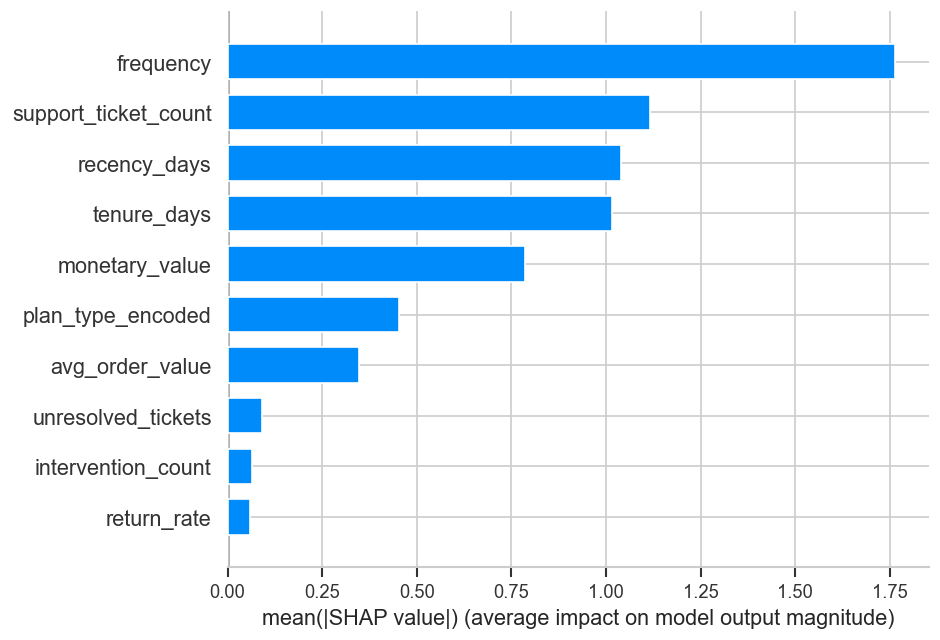

Top Churn Drivers (SHAP):


,Feature,SHAP Importance
1,frequency,1.764750
4,support_ticket_count,1.116486
0,recency_days,1.040066
7,tenure_days,1.016933
2,monetary_value,0.785556
9,plan_type_encoded,0.453727
3,avg_order_value,0.347646
5,unresolved_tickets,0.090296
6,intervention_count,0.065741
8,return_rate,0.059645


In [11]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# Summary
fig = plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'shap_summary.png', bbox_inches='tight', dpi=120)
plt.show()

# Top drivers
shap_importance = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'Feature': X.columns,
    'SHAP Importance': shap_importance
}).sort_values('SHAP Importance', ascending=False)

print('Top Churn Drivers (SHAP):')
display(shap_df)

In [ ]:
# Save model & scaler
joblib.dump(xgb_model, MODELS_DIR / 'churn_model.pkl')
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')

# Save metrics
metrics = {
    'test_roc_auc': float(xgb_test_auc),
    'test_pr_auc': float(xgb_test_prauc),
    'optimal_threshold': float(optimal_threshold),
    'feature_names': X.columns.tolist(),
}

import json
with open(OUTPUT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(' Model, scaler, and metrics saved')

✅ Model, scaler, and metrics saved


## Part 3 Complete 

### Deliverables
- **churn_model.pkl** — Trained XGBoost
- **metrics.json** — Model metrics & threshold
- **Charts** — ROC, confusion matrix, SHAP plots

### Key Outputs
- ROC-AUC: High discrimination between churners & non-churners
- PR-AUC: Good performance on imbalanced data
- Optimal Threshold: Maximizes retention ROI
- SHAP Explainability: Business-interpretable predictions

